# Оглавление

* [Случайный отбор и смещенная выборка](#Случайный-отбор-и-смещенная-выборка)
    * [Смещение](#Смещение)
* [Систематическая ошибка отбора](#Систематическая-ошибка-отбора)
* [Выборочное распределение статистической величины](#Выборочное-распределение-статистической-величины)
    * [Центральная предельная теорема](#Центральная-предельная-теорема)
    * [Стандартная ошибка](#Стандартная-ошибка)
* [Бутстрап](#Бутстрап)
* [Доверительные интервалы](#Доверительные-интервалы)
* [Нормальное распределение](#Нормальное-распределение)
* [Длиннохвостые распределения](#Длиннохвостые-распределения)
* [t-распределение Стьюдента](#t-распределение-Стьюдента)
* [Биномиальное распределение](#Биномиальное-распределение)
* [Распределение Хи-квадрат](#Распределение-Хи-квадрат)
* [F-распределение](#F-распределение)
* [Распределение Пуассона, Экспоненциальное распределение и распределение Вейбулла](#Распределение-Пуассона,-Экспоненциальное-распределение-и-распределение-Вейбулла)

In [1]:
%matplotlib inline

from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.utils import resample

import seaborn as sns
import matplotlib.pylab as plt

Для того чтобы можно было "попасть" из левой стороны в правую. используется процедура _отбора_. Традиционная статистика сосредоточена главным образом на левой стороне, используя теорию, основанную на серьезных допущениях о популяции. Современная статистика переместилась в правую сторону, где такие допущения не нужны.

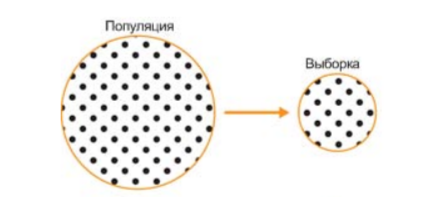

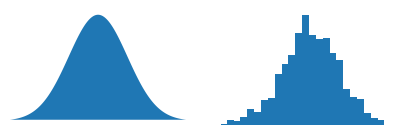

In [2]:
np.random.seed(seed=1)
x = np.linspace(-3, 3, 300)
xsample = stats.norm.rvs(size=1000)

fig, axes = plt.subplots(ncols=2, figsize=(5, 1.5))

ax = axes[0]
ax.fill(x, stats.norm.pdf(x))
ax.set_axis_off()
ax.set_xlim(-3, 3)

ax = axes[1]
ax.hist(xsample, bins=30)
ax.set_axis_off()
ax.set_xlim(-3, 3)
ax.set_position
# plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0)

plt.show()

Исследователям данных следует уделять основное внимание процедурам отбора и располагаемым данным. 

Любая реальная биномиальное ситуация (купить или не купить, мошенночество или не мошенничество, нажать или не нажать) может быть эффективно смоделированна монетой (разумеется, с подстроенной вероятностью приземления орла)

## Случайный отбор и смещенная выборка

__Выборка (sample)__ - это подмножество данных из более крупного набора данных (генеральной совокупности).

__Генеральная совокупность__ - (Популяция (population)) множество всех изучаемых элементов множетсва (объекты).
 
__Случайный отбор (random sampling)__ - это процесс, в котором каждый доступный член популяции, подвергаемый отбору, имеет равную возможность попасть в выборку при каждом извлечении. Отбор может быть выполнен с _возвратом_ и _без возврата_. 

__Стратифицированный отбор (stratified sampling)__ - разделение популяции на страты (подгруппы) и случайный отбор элементов из каждой страты. Популяция разделяется на страты и случайные выборки берутся из каждой страты.

__Простая случайная выборка (simple random sample)__ - выборка, получаемая в результате случайного отбора без разбиения популяции на страты.

__Смещенная выборка (sample bias)__ - выборка, которая  представляет популяцию в искаженном виде. Выборка отличается некоторым содержательным неслучайным характером от остальной более многочисленной  популяции.

Качество данных в науке о данных предусматривает полноту, соглосованность формата, чистоту и точность отдельных точек данных.

__Репрезентативность__ данных - соответствие характеристик выборки характеристикам популяции или генеральной совокупности в целом.

Символ $\bar{x}$, обозначающий среднее значение выборки из популяции, описывает и в лучшем случае равняется $\mu$, обозначающее среднее значение по всей популяции. 

### Смещение

Статистическое смещение относится у _ошибкам измерения_ или _отбора_. Важно проводить различие между ошибками вследствие  случайности и ошибками вследствие смещения. Смещение возникает в разных формах и может быть заметным и незаметным.

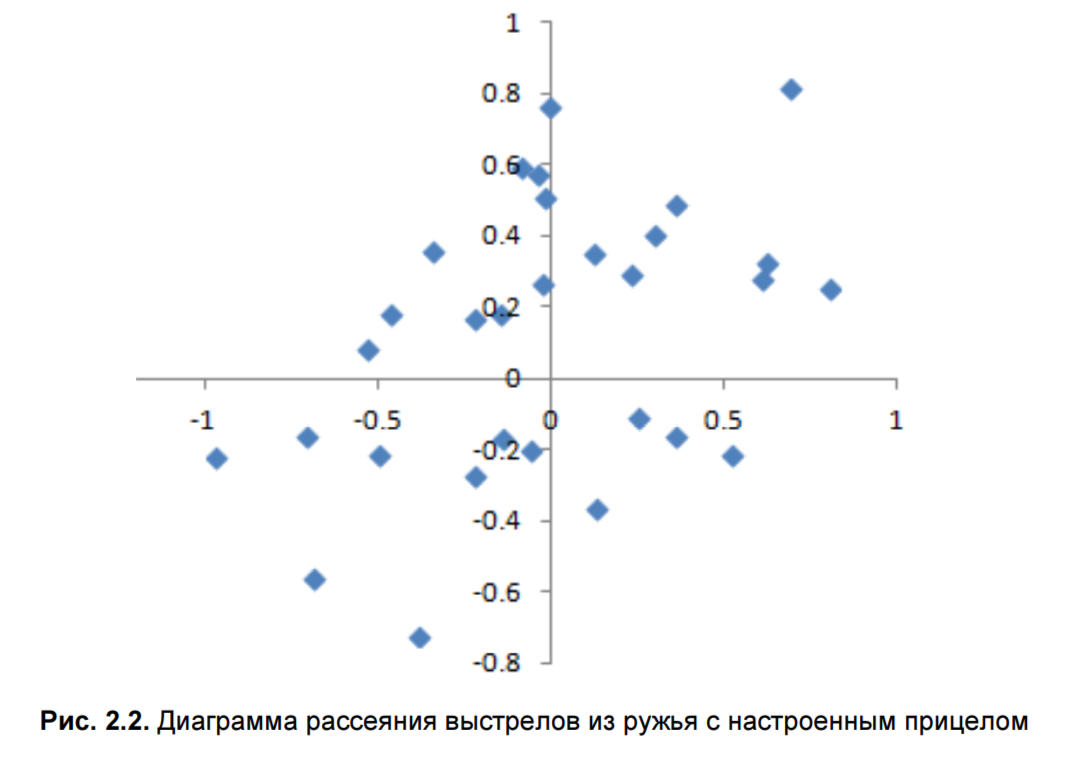

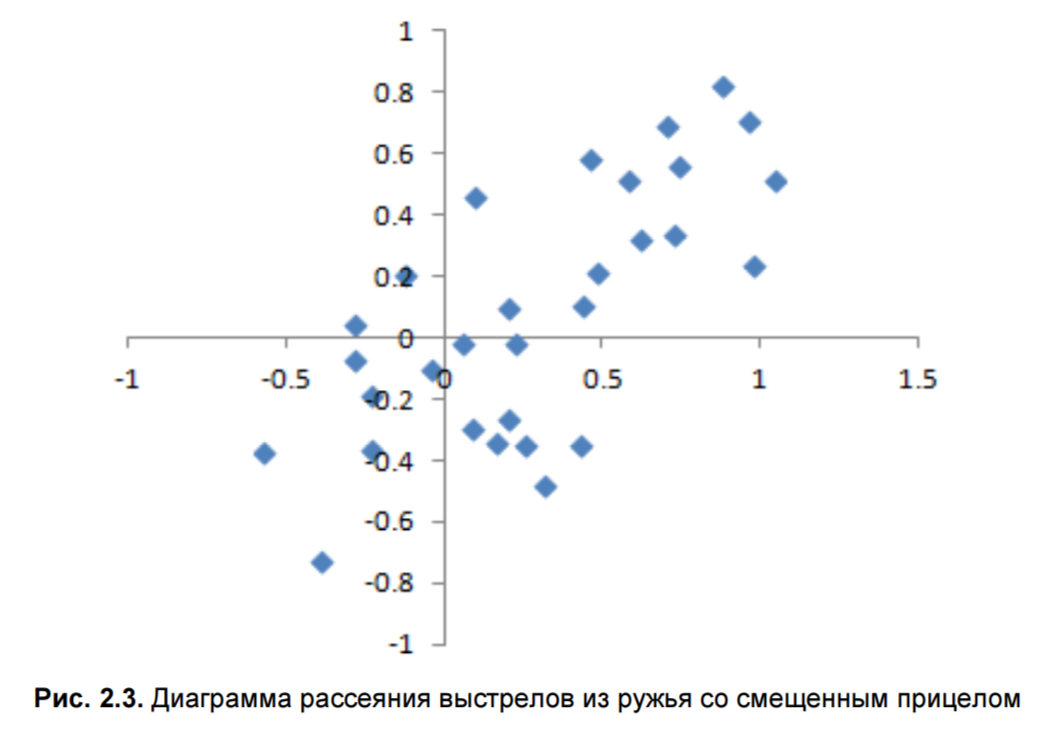

## Систематическая ошибка отбора

__Систематическая ошибка отбора (selection bias)__  относится к практике избирательного подбора данных.

__Смещение (bias)__ - систематическая ошибка.

__Прочесывание данных (data snooping)__ - подробная ревизия данных с целью найти что-то интересное.

__Эффект бескрейнего поиска (vast search effect)__ - смещение или невоспроизводимость, вытекающие из многократного моделирования данных либо моделирования данных с большим числом предсказательных переменных. Форма систематической ошибки отбора, имеющая особое значение  для исследователей данных (Элдер Джон).

__Перетасовка целей (target shuffling)__ - для проверки достоверности, предсказательных ассоциаций , которые предлагает модель добычи регулярностей из данных.

## Выборочное распределение статистической величины

"Выборочное распределение" статистической величины обозначает распределение некоторой выборочной статистики над многочиленными выборками, извлекаемыми из одной и той же популяции.

__Выборочная статистика (sample statistics)__ - метрика, которая вычисляется для выборки данных, извлекаемой из более крупной популяции.

__Статистика__ - числовая величина, описывающая выборку из популяции.

__Распределение данных (data distribution)__ - частотное распределение индивидуальных значений в наборе данных.

__Выборочное распределение (sampling distribution)__ - (распределение выборки) частное распределение _выборочной статистики_ над многочисленными выборками или повторными выборками. 

__Выборочное распределение статистики__ - это распределение этой статистики для всех возможных выборок фиксированного размера _n_, взятых из популяции.

__Центральная предельная теорема (central limit theorem)__ - (ЦПТ) тенденция выборочного распределения принимать нормальную форму по мере увеличения размера выборки.

__Стандартная ошибка (standard error)__ - вариабельность (стандартное отклонение) выборочной статистики над много численными выборками (не путать со стандартным отклонением, которое как таковое относится к вариабельности индивидуальных значений данных).

При извлечении выборки, ключевой проблемой является _выборочная вариабельность_. Также важно, проводить различие между распределением индивидуальных точек данных, именнуемым _распределением данных_, и распределением выборочной статистики, именуемым _выборочным распределением_.

Распределение выборочной статистики, такой как среднее, вероятно, будет более регулярным и колокообразным, чем распределение самих данных.

In [3]:
loans_income = pd.read_csv('data/loans_income.csv').squeeze('columns')

sample_data = pd.DataFrame({
    'income': loans_income.sample(1000),
    'type': 'Data',
})

sample_mean_05 = pd.DataFrame({
    'income': [loans_income.sample(5).mean() for _ in range(1000)],
    'type': 'Mean of 5',
})

sample_mean_20 = pd.DataFrame({
    'income': [loans_income.sample(20).mean() for _ in range(1000)],
    'type': 'Mean of 20',
})

results = pd.concat([sample_data, sample_mean_05, sample_mean_20])
print(results.head())

         income  type
40292   63000.0  Data
38959   92000.0  Data
17361  134000.0  Data
33996   52000.0  Data
26491   43000.0  Data


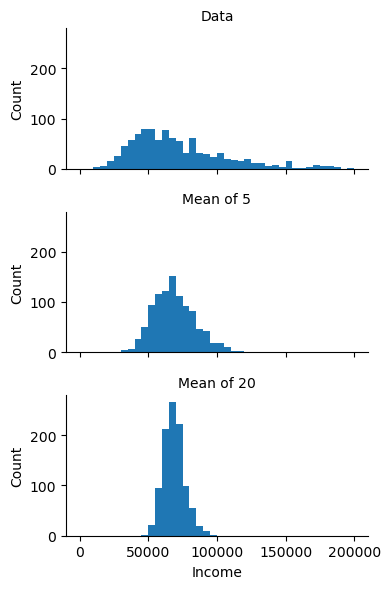

In [5]:
# класс FaceGrid пакета seaborn для изображения трех гистограмм
g = sns.FacetGrid(results, col='type', col_wrap=1, 
                  height=2, aspect=2)
g.map(plt.hist, 'income', range=[0, 200000], bins=40)
g.set_axis_labels('Income', 'Count')
g.set_titles('{col_name}')

plt.tight_layout()
plt.show()

### Центральная предельная теорема

Центральная предельная теорема - выше указанный пример, где средние значения, извлеченные из многочисленных выборок могут напоминать колокообразную нормальную кривую, даже если исходная популяция не является нормально распределенной, при условии, что размер выборок достаточно крупный и отступление данных от нормальности не слишком большое. ЦПТ позволяет использовать нормально-аппроксимационные формулы, такие как t-распределения в вычислении доверительных интервалов и проверки гипотез.

### Стандартная ошибка

__Стандартная ошибка (se)__ - это одиночная метрика, которая обощает вариабельность статистической величины в выборочном распределении. $$se = \frac{s}{\sqrt{n}}$$ По мере увеличения размера выборки стандартная ошибка уменьшается. Связь между стандартной ошибкой и размером выборки иногда носит название __правила квадратного корня из n__: для сокращения стандартной ошибки в 2 раза размер выборки должен быть увеличен в 4 раза.

Не путать стандартное отклонение (которое показывает  вариабельность отдельных точек данных) со стандартной ошибкой (которая показывает вариабельность выборочной метрики).

## Бутстрап

__Бутстрап (от англ. bootstrap - раскрутка, самонастройка, исходно)__ - Один из простых и эффективных способов оценивания выборочного распределения  статистической величины или модельных параметров состоит в том, чтобы извлекать дополнительные выборки с возвратом из самой выборки и перевычислять статистику или модель для каждой повторной выборки. _И она __не__ сопряжена с какими-либо допущениями о том, что данные или выборочная статистика нормально распределены_. Бутстрап используется для определения надежности оценок.

__Бутстраповская выборка (bootstrap sample)__ - выборка, взятая с возвратом из набора наблюдаемых данных.

__Повторный отбор (resampling)__ - процесс многократного взятия выборок из наблюдаемых данных, включает процедуры бутстрапа и перестановки (пермутации). Повторный отбор - это любой метод генерирования новой выборки из существующего набора данных.

Иногда "повторный отбор" и "бутстрапирование" исользуются как синонимы. Чаще "повторный выбор" также включает процедуры пермутации. А бутстрап всегда подразумевает выборку из наблюдаемого набора данных с возвратом.

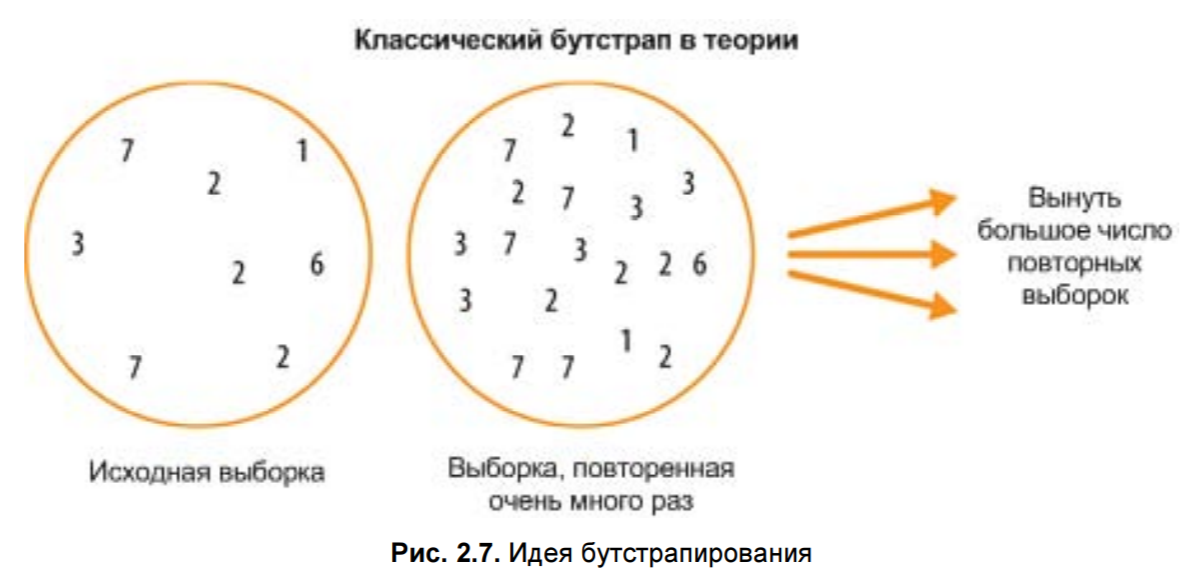

Концептуально, бутстрап это репликация исходной выборки тысячи или миллионы раз, чтобы получить гипотетическую популяцию, которая обладает всеми характеристиками оригинальной выборки, просто превосходящая размерами. Затем из гипотетической популяции можно извлекать выборки с целью оценивания выборочного распределения.

На практике упрощается подход, делая просто выборку с возвратом. Алгоритм бутстраповского повторного отбора среднего значения для выборки размера _n_:
1. Извлечь выборочное значение, записать его и вернуть назад;
2. Повторить n раз;
3. Записать среднее для _n_ повторно отобранных значений;
4. Повторить R раз первые три шага;
5. Использовать R результатов, чтобы:
    * вычислить их стандартное отклонение (они оценивают стандартную ошибку выборочного среднего);
    * построить гистограмму или коробчатую диаграмму;
    * найти доверительный интервал.

In [6]:
# с помощью метода resample пакеты scikit-learn
results = []
for nrepeat in range(1000):
    sample = resample(loans_income)
    results.append(sample.median())
results = pd.Series(results)
print('Bootstrap Statistics:')
print(f'original: {loans_income.median()}')
print(f'bias: {results.mean() - loans_income.median()}')
print(f'std. error: {results.std()}')

Bootstrap Statistics:
original: 62000.0
bias: -82.09799999999814
std. error: 228.73933106830748


Бутстрап можно использовать с многомерными данными, где строки отбираются как единное целое. Что касается классифицированных и регрессионных деревьев (деревья решений), то выполнение многочисленных деревьев на бутстраповских выборках и далее усреднение их предсказаний. Обычно оказывает результативнее, чем использование одного-единственного дерева. Этот процесс называется __бэггингом__ (от англ. bootstrap aggregating - агрегирование бутстправоских выборок.

Бутстрап не компенсирует малый размер выборки; он не создает новые данные и при этом не заполняет дыры в существующем наборе данных. Он просто сообщает о том, как поведут себя многочисленные дополнительные выборки, когда они будут извлекаться из популяции, такой как исходная выборка.

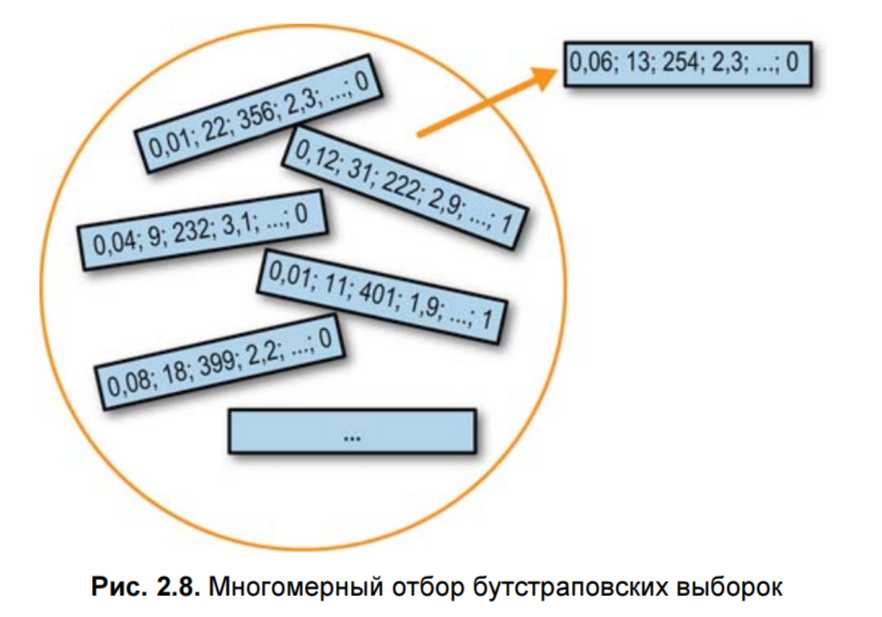

## Доверительные интервалы

__Уровень доверия (confidence level)__ - процент доверительных интервалов, сконструированных одинаковым образом из одной и той же популяции, которые ожидаемо будут содержать целую статистику.

__Конечные точки интервала (interval endpoints)__ - верх и низ доверительного интервала.

Аналитики и менеджеры неоправданно доверяются оценке, когда она представлена единственным числом (_точечной оценкой_)

В более общем случае, х%-ый доверительный интервал вокруг выборочной оценки должен в среднем содержать похожие выборочные оценки в х% случаев. 

С учетом выборки размера _n_ и целевой выборочной статистики алгоритм для бутстраповского доверительного интервала следующий:
1. Извлечь из данных случайную выборку размера _n_ с возвратом;
2. Записать целевую статистику для повторной выборки;
3. Повторить первые два шага R раз;
4. Для x%-ного доверительного интервала отсечь [(1-[x/100)/2]% от R результатов повторного отбора с обоих концов;
5. В качестве точек отсечения принять конечные точки х%-ного бутстраповского доверительного интервала.

68760.51844
55734.1


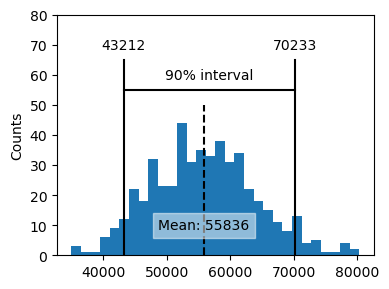

In [7]:
print(loans_income.mean())
np.random.seed(seed=3)  
# create a sample of 20 loan income data
sample20 = resample(loans_income, n_samples=20, replace=False)
print(sample20.mean())
results = []
for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [55, 55], color='black')
for x in confidence_interval:
    ax.plot([x, x], [0, 65], color='black')
    ax.text(x, 70, f'{x:.0f}', 
            horizontalalignment='center', verticalalignment='center')
ax.text(sum(confidence_interval) / 2, 60, '90% interval',
        horizontalalignment='center', verticalalignment='center')

meanIncome = results.mean()
ax.plot([meanIncome, meanIncome], [0, 50], color='black', linestyle='--')
ax.text(meanIncome, 10, f'Mean: {meanIncome:.0f}',
        bbox=dict(facecolor='white', edgecolor='white', alpha=0.5),
        horizontalalignment='center', verticalalignment='center')
ax.set_ylim(0, 80)
ax.set_ylabel('Counts')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Counts')

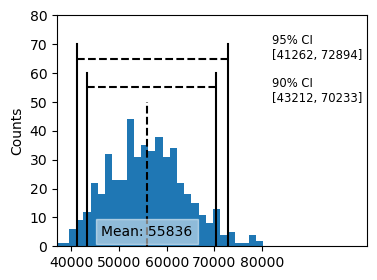

In [8]:
np.random.seed(seed=3)
# create a sample of 20 loan income data
sample20 = resample(loans_income, n_samples=20, replace=False)

results = []
for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(4, 3), color='C1')
ax.plot(confidence_interval, [55, 55], color='black', linestyle='--')
for x in confidence_interval:
    ax.plot([x, x], [0, 60], color='black')
ax.text(82000, 50, 
        f'90% CI\n[{confidence_interval[0]:.0f}, {confidence_interval[1]:.0f}]',
       fontsize='small')

confidence_interval = list(results.quantile([0.025, 0.975]))
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [65, 65], color='black', linestyle='--')
for x in confidence_interval:
    ax.plot([x, x], [0, 70], color='black')
ax.text(82000, 65, 
        f'95% CI\n[{confidence_interval[0]:.0f}, {confidence_interval[1]:.0f}]',
       fontsize='small')
# ax.text(sum(confidence_interval) / 2, 264, '95 % interval',
#         horizontalalignment='center', verticalalignment='center')

meanIncome = results.mean()
ax.plot([meanIncome, meanIncome], [0, 50], color='black', linestyle='--')
ax.text(meanIncome, 5, f'Mean: {meanIncome:.0f}',
        bbox=dict(facecolor='white', edgecolor='white', alpha=0.5),
        horizontalalignment='center', verticalalignment='center')
ax.set_ylim(0, 80)
ax.set_xlim(37000, 102000)
ax.set_xticks([40000, 50000, 60000, 70000, 80000])
ax.set_ylabel('Counts')

# plt.tight_layout()
# plt.show()

Процент, связанный с доверительным интервалом, называется __уровенем доверия__. Чем выше уровень доверия, тем шире интервал. Чем меньше выборка, тем шире интервал (т.е. тем больше неопределенность).

##  Нормальное распределение

Нормальное распреление также называется _гауссовским распределением_ в честь Карла Фридриха Гаусса. Для нормального распределения есть еще одно название - распределение "ошибок". С точки зрения статистики ошибка - это разница между фактическим значением и статистической оценкой.

__Ошибка (error)__ - (погрешность) разница между точкой данных и предсказанным средним значением.

__Стандартизировать (standardize)__ - вычесть среднее значение и разделить стандартное отклонение.

__Z-оценка (z-score)__ - (стандартная оценка, z-балл) результат стандартизации отдельной токи данных.

__Стандартное нормальное распределение (standard normal distribution)__ - нормальное распределение со средним, равным 0, и стандартным отклонением, равным 1. Это такое распределение, в котором единицы на оси х выражены в стандартных отклонениях от среднего. Для того чтобы сравнить данные со стандартным нормальным распределением, нужно вычесть среднее значение и затем разделить на стандартное отклонение: эта процедура называется _нормализацией_ или _стандартизацией_. Преобразованное число называется _z-оценкой_ или _стандартной оценкой_, в нормальное распределение иногда называют _z-распределением_.

__Квантиль-квантильный график (QQ-plot)__ - (QQ-график) график, позволяющий визуализировать степень близости выборочного распределения к нормальному распределению.

В нормальном распределении 68% данных находятся в пределах одного стандартного отклонения от среднего и 95% - в пределах двух стандартных отклонений.

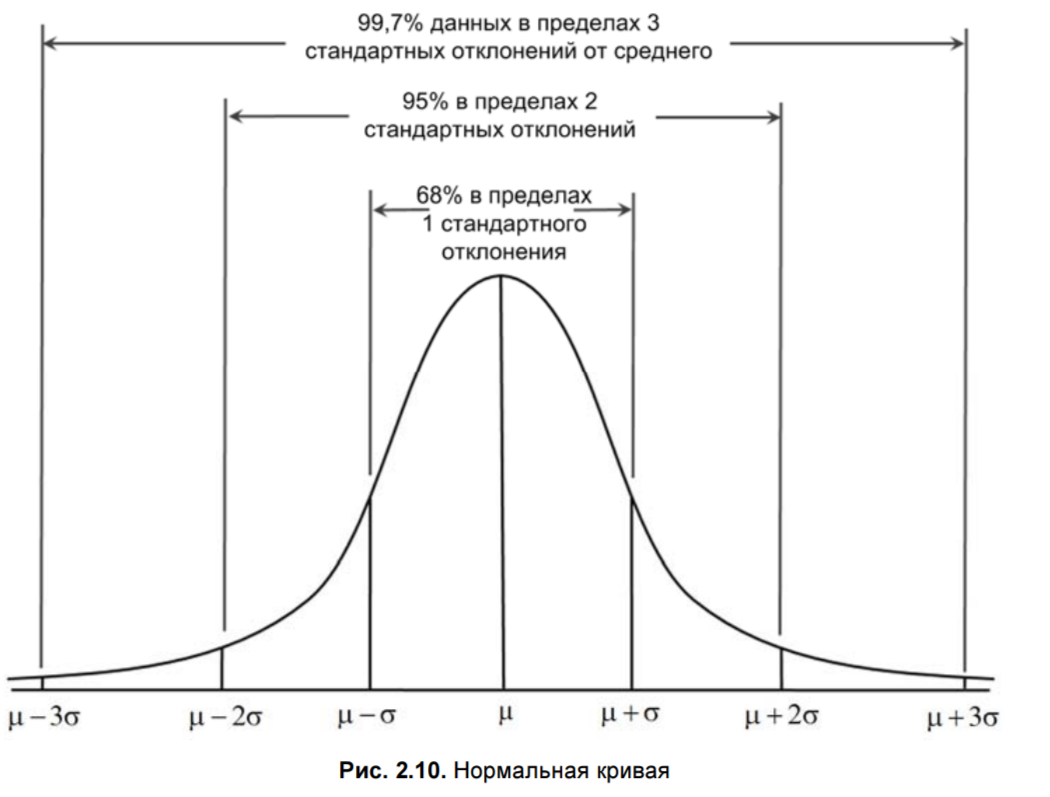

Большинство переменных используемых в типичном проекте науки о данных - по сути дела, большинство сырых данных в целом, - не являеются нормально распределенными.

Допущения о нормальности являются крайней мерой, обычно используемой, когда эмпирические вероятностные распределения, или бутстраповские распределения отсутствуют.

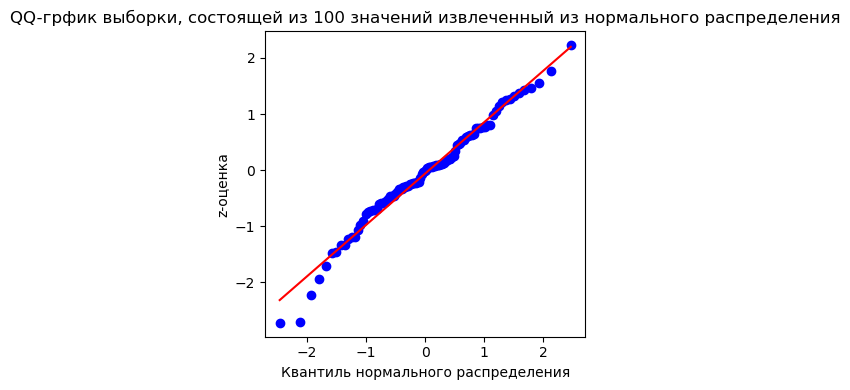

In [14]:
# квантиль-квантильный график используя scipy.stats.probplot
fig, ax = plt.subplots(figsize=(4, 4))

norm_sample = stats.norm.rvs(size=100)
stats.probplot(norm_sample, plot=ax)

ax.set_xlabel("Квантиль нормального распределения")
ax.set_ylabel("z-оценка")
ax.set_title('QQ-грфик выборки, состоящей из 100 значений извлеченный из нормального распределения')

plt.tight_layout()
plt.show()

## Длиннохвостые распределения

__Хвост (tail)__ - длинная узкая часть частотного распределения, где относительно предельные значения встречаются с низкой частотой.

__Ассиметрия (skew)__ - (скошенность) состояние, когда один хвост распределения длинее другого.

Иногда распределение сильно скошено (ассиметрично). И симметричные и ассемитричные распределения могут иметь длинные хвосты.

Один из методов против длинных хвостов _черный лебедь_ предложенный Нассим Талебом, который прежсказывает, что аномальные события могут возникать с намного большей вероятностью, чем их предсказание нормальным распределением.

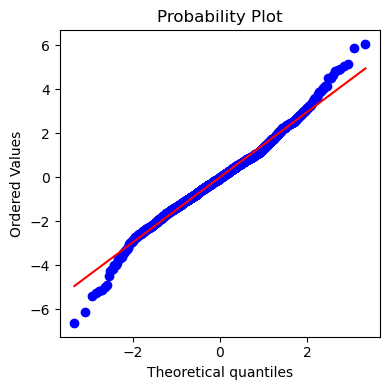

In [16]:
sp500_px = pd.read_csv('data/sp500_data.csv.gz')

nflx = sp500_px.NFLX
nflx = np.diff(np.log(nflx[nflx>0]))

fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(nflx, plot=ax)

plt.tight_layout()
plt.show()

## t-распределение Стьюдента

Распределение Стьюдента или t-распределение - это распределение нормальной формы, но немного толще и длинее в хвостах. Чем больше выборка, тем более нормальную форму принимает t-распределение.

__Степени свободы (degrees of freedom)__ - параметр, который позволяет t-распределению адаптироваться к разным размерам выборок, статистикам и числам групп.

t-Распределение так называют, потому что оно было опубликовано в 1908 году в журнале "Биометрика" У.С.Госсеттом (W.S.Gossett) под всевдонимом "Студент". - http://seismo.berkeley.edu/~kirchner/eps_120/Odds_n_ends/Students_original_paper.pdf

Выборку размера _n_ с выборочным средним $\bar{x}$. Если s - это выборочное стандартное отклонение, то 90%-ный доверительный интервал вокруг выборочного среднего создается следующей формулой: $$\bar{x}\pm t_{n-1}(0,05)*\frac{s}{t}$$, где $t_{n-1}(0,05)$-это значение t-статистики с (n-1) степенями свободы, которое отсекает 5% t-распределения с обоих концов.

t-Рапсределение используется в классическом статистическом выводе, но оно не имеет столь важного значения для целей науке о данных. Данное распределение относится к семействе распределений близких к нормальному распределению, но с более толстыми хвостами. t-Распределение широко используется в качестве эталонного базиса для распределения выборочных средних, разниц между двумя выборочными средними, параметров регрессии и т.д.

## Биномиальное распределение

Такие исходы в форме да/нет или 0/1 называются двоичными.

__Испытание (trial)__ - событие с дискретным исходом.

__Успех (success)__ - интересующий результат испытания.

__Биномаильный (binomial)__ - (двоичный, бинарный, двучленный) имеющий два исхода.

__Биномиальное испытание (binomial trial)__ - (бернуллиево испытание) испытание с двумя исходами.

__Биномальное распределение (binomial distribution)__ - (бернуллиево распределение) распределение числа успехов в _х_ испытаниях.

Биномиальное распределение - это частное распределение числа успехов (х) в заданном числе испытаний (n) с указанной вероятностью (р) успеха в каждом из испытании.

Среднее биномиального распределения равно __n*p__.

Дисперсия равна __n*p*q__, где q=(1-р). 

In [18]:
# модуль scipy.stats имплементирует большое количество рапсределений
# для биномиального рапсределения stats.binom.pmf и stats.binom.cdf
print(stats.binom.pmf(2, n=5, p=0.1))
print(stats.binom.cdf(2, n=5, p=0.1))

0.07289999999999992
0.99144


## Распределение Хи-квадрат

Важной идеей в сатитистике является _отступление от ожидания_ также называемое _нулевой гипотезой_ или _нулевой моделью_. Статистическая величина , которая измеряет степень отступления результатов от нулевого ожидания независимости , называется статистикой Хи-квадрат, обозначается $\chi^2$. Это указанная разница между наблюдаемыми и ожидаемыми значениями, деленная на квадратный корень из ожидаемого значения, возведенная в квадрат, а затем суммированная по всем категориям. 

Низкое значение хи-квадрат для набора количественных данных указывает на то, что они точно следуют ожидаемому распределению. Высокий хи-квадрат указывает на то, что они заметно отличаются от того, что ожидается.

Распределение хи-квадрат обязан своим местом ститистику Карлу Пирсону. Об этом можно проитать в книге Дэвида Салсбурга "Леди дегустирует чай: как статистика революционизировала науку в двадцатом веке".

## F-распределение

F-статистика измеряет степень, которая различия между средними значениями групп больше, чем можно было бы ожидать при нормальной случайной вариации, и представляет собой отношение вариабельности между средними группами к вариабельности внутри каждой группы (так называемую остаточную вариабельность). Это сравнение называется _дисперсионным анализом_. Распределение F-статистики - это частное распределение всех значений, которые были бы получены путем случайной перестановки данных, в которых все групповые средние равны (т.е. нулевая модель). F-статистика также используется в линейной регрессии для сравнения вариации, объясняемой регрессионной моделью, с совокупной вариацией в данных. F-статистика автоматически производится  в языках R и Python в рамках процедур регрессионного и дисперсионного анализа.

## Распределение Пуассона, Экспоненциальное распределение и распределение Вейбулла

__Лямбда (lambda)__ - интенсивность (в расчете на единицу времени или пространства), с которой происходят события.

__Распределение Пуассона (Poisson distribution)__ - частотное распределение числа событий в отобранных единицах  времени или пространства. Если нужно узнать, насколько среднестатистическое число событий может отличаться от одной единицы времени/пространства к другой. Ключевым параметром является $\lambda$ - это среднее число событий, которое происходит в указанный интервал времени или пространства. Диспресия распределения тоже равна $\lambda$.

__Экспоненциальное распределение (exponential distribution)__ - частотное распределение времени или расстояния от одного события до следующего события. Можно смоделировать распределение времени между событиями с тем же параметром $\lambda$.

Интенсивность __лямбда $\lambda$__ остается постоянной в течение рассматриваемого периода. Чаще интенсивность события события $\lambda$ известна, но также ее можно оценить из предшесовующих данных. Если данные имеются но их недостаточно для того, чтобы обеспечить точную, надежную оценку интенсивности, то к различным интенсивностям может быть применена проверка оптимальности подгонки, чтобы можно было определить, насколько хорошо они соответствуют наблюдаемым данным.

__Распределение Вейбулла (Weibull distribution)__ - обобщенная версия экспоненциального распределения, в котором допускается смещение интенсивности события во времени. Во многих случаях интенсивность события не остается постоянной во времени. Если же интенсивность события изменяется внутри временного интервала, то экспоненциального и пуассоновского распределения больше не приносят пользы. _Распределение Вейбулла_ является расширением экспоненциального распределения, в котором допускается изменение интенсивности события в соответствии с _параметром формы $\beta$_. Если $\beta$>1, то вероятность события увеличивается во времени, если $\beta$<1, то она уменьшается. Вместо интенсивности события, второй параметр выражен с точки зрения характерного времни жизни. _Параметр масштаба_ или _шкалы_ $\eta$ - это параметр вероятностного распределения, чье физическое конкретное значение связанно с выбором шкалы измерения.

С распределением Вейбулла задача оценивания теперь предусматривает оценивание двух параметров: $\beta$ и $\eta$.

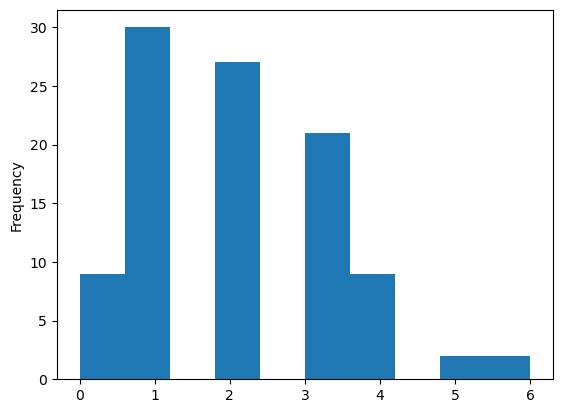

In [21]:
# Рапсределение Пуассона
sample = stats.poisson.rvs(2, size=100)

pd.Series(sample).plot.hist()
plt.show()

In [22]:
# stats.wxpon.rvs сгенерирует 100 случайных чисел из экспоненциального распределения,
# где среднее число событий в расчете на париод времени равно 2.
# код можно спользовать для моделирования 100 интервалов  в минутах между сервисными вызовами,
# где средняя интенсивность входящих вызовов равна 0.2 в минуту
stats.expon.rvs(0.2, size=100)

array([3.37338921, 0.84982723, 0.20321471, 1.89526114, 0.59031656,
       1.05251959, 0.23640861, 2.76730755, 0.29356297, 1.22375139,
       0.20395172, 0.87404452, 0.23340962, 1.454927  , 1.18198994,
       0.93618639, 0.98803917, 0.214612  , 0.50440925, 2.93865551,
       1.80630688, 1.30103476, 0.54897543, 1.50811797, 1.81791204,
       0.22234072, 0.25120445, 0.57393315, 3.56780558, 0.47188609,
       1.24417727, 0.97683792, 2.28405356, 1.13862118, 0.75822106,
       1.27088484, 0.36569719, 0.91137562, 1.27888371, 4.44437125,
       0.64831122, 0.68609848, 0.46053862, 0.58564768, 0.66908759,
       0.41492523, 1.70637569, 0.94120799, 1.4889595 , 0.57980869,
       0.5858802 , 0.30505555, 0.7025428 , 0.4357684 , 0.49002742,
       3.57830503, 1.03034606, 2.08731435, 2.49730717, 1.99405145,
       0.46622102, 0.37501063, 0.56724699, 0.84583249, 0.31879417,
       1.37455431, 0.78962396, 1.49443292, 0.87282853, 0.61451575,
       0.50300179, 0.58163108, 1.79489446, 0.7890571 , 3.82251

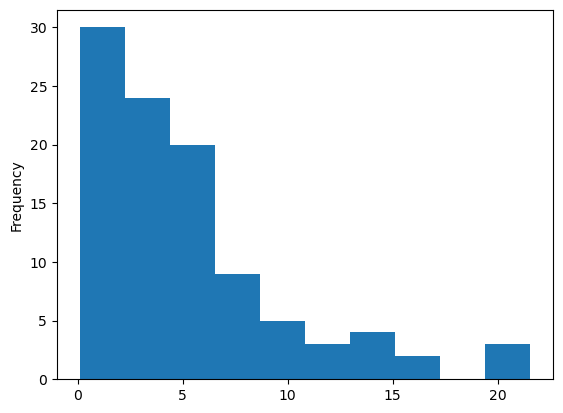

In [23]:
sample = stats.expon.rvs(scale=5, size=100)

pd.Series(sample).plot.hist()
plt.show()

In [24]:
# stats.weibull_min.rvs функция в Python
stats.weibull_min.rvs(1.5, scale=5000, size=100)

array([ 8640.36608128,   891.49467118,  5197.8064999 ,  7086.3549391 ,
        2540.36474465,  6239.42841144,  1583.35069432,  4761.74055971,
        4868.28071212,  1800.76387683,  7518.78233357,  2128.46961785,
        6320.00847462,  2503.6646923 ,  4286.93326307,  1888.43620059,
        6420.89944704,  4622.48144174,  1861.16412089,  4286.07799463,
        4352.67267172,  7347.46278616, 16593.02898762,  8516.09552763,
         882.08658412,  1487.08290709, 10312.31297337,  1647.47598995,
        3980.75726842,  7894.22964704,  3889.7121598 ,   819.31215761,
        4900.10879765,  3029.25969953,  4314.42046593,  9933.27954983,
        5433.89490441,  2560.11884936,  3618.34474516,  2861.6161389 ,
        3597.92128659,  1123.46160564,  4342.92922948,  6346.42029923,
       10979.2166501 ,  1086.2591467 ,  5734.24883459,  5178.92500176,
        4488.48256383,  2505.94041247,  4817.7962046 ,  1792.82069701,
        1892.75590303,  6572.52720934,  3375.63546688,  7189.3267542 ,
      

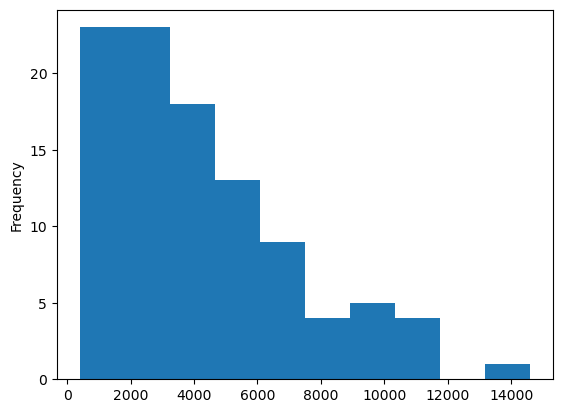

In [25]:
sample = stats.weibull_min.rvs(1.5, scale=5000, size=100)

pd.Series(sample).plot.hist()
plt.show()